In [1]:
import os
import platform

print(f"sistem operasi  : {platform.system()} {platform.release()}")
print(f"Arsitektur      : {platform.machine()}")
print(f"Prosesor        : {platform.processor() or 'tidak terdeteksi'}")
print(f"Jumlah CPU Logis: {os.cpu_count()}")


sistem operasi  : Windows 8.1
Arsitektur      : AMD64
Prosesor        : AMD64 Family 20 Model 2 Stepping 0, AuthenticAMD
Jumlah CPU Logis: 2


In [5]:
import numpy as np
import time

#il
N = 2_000_000
data = list(range(N))

#gaya sisd:
start = time.perf_counter()
hasil_sisd = [x*2 for x in data]
waktu_sisd = time.perf_counter()-start

#gaya simd
arr = np.array(data)
start = time.perf_counter()
hasil_simd = arr*2
waktu_simd = time.perf_counter() - start

print(f"Gaya SISD (LIST OF COMPERHENSION     : {waktu_sisd:.4f} detik")
print(f"Gaya SIMD (Numpy vectorized)         : {waktu_simd:.4f} detik")
print(f"NumPy lebih cepat sekitar {waktu_sisd/waktu_simd:.1f}x")

Gaya SISD (LIST OF COMPERHENSION     : 1.0184 detik
Gaya SIMD (Numpy vectorized)         : 0.0492 detik
NumPy lebih cepat sekitar 20.7x


In [6]:
# Demonstrasi ringan: dampak GIL pada beban kerja CPU-bound
# (Perbandingan lengkap threading vs multiprocessing akan dibahas detail di Pertemuan 2 & 3)

import threading
import time

def cpu_bound_task(n):
    # Fungsi CPU-bound sederhana: menjumlahkan kuadrat hingga n
    total = 0
    for i in range(n):
        total += i * i
    return total

N = 5_000_000

# --- Eksekusi SEKUENSIAL (baseline) ---
start = time.perf_counter()
cpu_bound_task(N)
cpu_bound_task(N)
waktu_sequential = time.perf_counter() - start

# --- Eksekusi dengan 2 THREAD (harusnya TIDAK banyak membantu karena GIL) ---
start = time.perf_counter()
t1 = threading.Thread(target=cpu_bound_task, args=(N,))
t2 = threading.Thread(target=cpu_bound_task, args=(N,))
t1.start(); t2.start()
t1.join(); t2.join()
waktu_threading = time.perf_counter() - start

print(f"Sekuensial (2x panggilan biasa) : {waktu_sequential:.3f} detik")
print(f"Menggunakan 2 thread             : {waktu_threading:.3f} detik")
print(f"Speedup threading                : {waktu_sequential/waktu_threading:.2f}x (bandingkan dengan harapan 2")


Sekuensial (2x panggilan biasa) : 6.988 detik
Menggunakan 2 thread             : 5.470 detik
Speedup threading                : 1.28x (bandingkan dengan harapan 2


In [8]:
# In:
import sys

print("Versi Python:", sys.version)
print(
    "Implementasi:", sys.implementation.name
)  # harus 'cpython' agar pembahasan GIL relevan



Versi Python: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
Implementasi: cpython


In [7]:
# In:
# Cek ketersediaan library yang akan sering dipakai sepanjang mata kuliah ini
import importlib

libraries = [
    "numpy",
    "pandas",
    "matplotlib",
    "joblib",
    "dask",
    "ray",  
    "numba",  
    "mpi4py",  
]

print(f"{'Library':<12} | Status")
print("-" * 30)
for lib in libraries:
    try:
        mod = importlib.import_module(lib)
        versi = getattr(mod, "__version__", "?")
        print(f"{lib:<12} | ✅ terpasang (v{versi})")
    except ImportError:
        print(f"{lib:<12} | ❌ belum terpasang")


Library      | Status
------------------------------
numpy        | ✅ terpasang (v2.2.6)
pandas       | ❌ belum terpasang
matplotlib   | ✅ terpasang (v3.10.8)
joblib       | ❌ belum terpasang
dask         | ❌ belum terpasang
ray          | ❌ belum terpasang
numba        | ❌ belum terpasang
mpi4py       | ❌ belum terpasang


In [2]:
""" No 1: Klasifikasi FLynn untuk masing-masing skenario beserta alasannya:

1. Operasi arr * arr pada NumPy array

Kategori: SIMD (Single Instruction, Multiple Data)

Alasan: NumPy dirancang untuk komputasi tervektorisasi. Saat Anda melakukan operasi arr * arr, CPU menggunakan satu instruksi yang sama (perkalian) dan menerapkannya secara serentak ke banyak titik data (elemen-elemen di dalam array), sering kali memanfaatkan instruksi vektor pada prosesor modern seperti AVX atau SSE.

2. Program Python biasa (tanpa threading/multiprocessing) yang membaca file lalu memproses baris demi baris

Kategori: SISD (Single Instruction, Single Data)

Alasan: Program Python default berjalan pada single-thread dan dieksekusi secara sekuensial (berurutan). CPU menjalankan satu aliran instruksi (logika pemrosesan) pada satu potongan data (baris file saat itu) secara bergantian hingga selesai.

3. Cluster komputer yang masing-masing node menjalankan simulasi cuaca berbeda untuk wilayah berbeda secara independen

Kategori: MIMD (Multiple Instruction, Multiple Data)

Alasan: Terdapat banyak unit pemrosesan (node di dalam cluster) yang beroperasi secara otonom. Karena setiap node menjalankan simulasi yang berbeda, mereka mengeksekusi aliran instruksi yang berbeda (Multiple Instruction), dan karena mereka memproses wilayah yang berbeda, mereka menggunakan kumpulan data yang berbeda pula (Multiple Data).
"""

' Klasifikasi FLynn '

N	Speedup
---------------
2	1.74
4	2.76
8	3.90
16	4.92
32	5.66
64	6.12


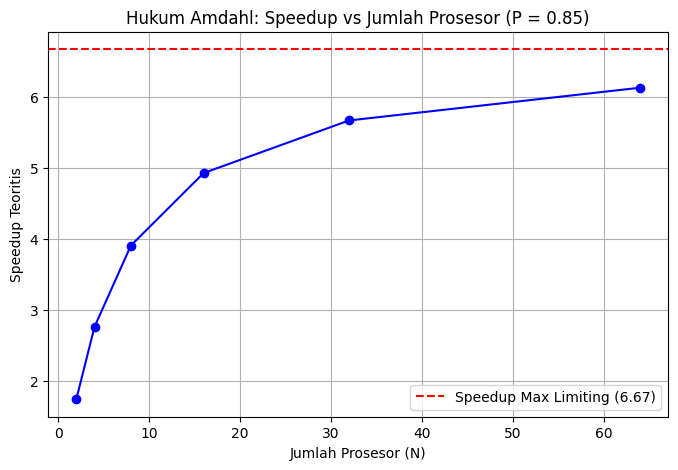

In [9]:
""" No 2: Analisis hukum Amdahl"""


import matplotlib.pyplot as plt
import numpy as np


def amdahl_speedup(P, N):
  return 1 / ((1 - P) + (P / N))


P = 0.85
N_values = [2, 4, 8, 16, 32, 64]
speedups = [amdahl_speedup(P, n) for n in N_values]

# Print Tabel Hasil
print("N\tSpeedup")
print("-" * 15)
for n, s in zip(N_values, speedups):
  print(f"{n}\t{s:.2f}")

# Plot Speedup vs N
plt.figure(figsize=(8, 5))
plt.plot(N_values, speedups, marker="o", color="b", linestyle="-")
plt.title("Hukum Amdahl: Speedup vs Jumlah Prosesor (P = 0.85)")
plt.xlabel("Jumlah Prosesor (N)")
plt.ylabel("Speedup Teoritis")
plt.grid(True)
plt.axhline(
    y=1 / (1 - P),
    color="r",
    linestyle="--",
    label=f"Speedup Max Limiting ({1/(1-P):.2f})",
)
plt.legend()
plt.show()

   Input Size (N)  perf_counter (s)  timeit (s)
0            5000          0.030887    0.029884
1           10000          0.065080    0.072752
2           20000          0.149865    0.155887
3           40000          0.347857    0.366487


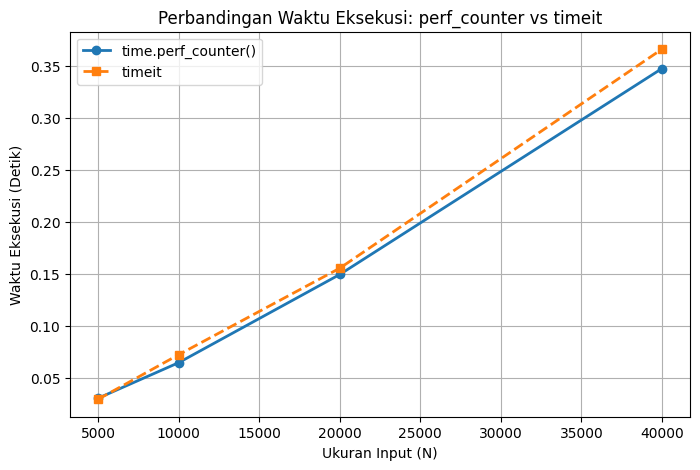

In [3]:
""" SOal no 3: BenchMark mandiri"""
import time
import timeit
import matplotlib.pyplot as plt
import pandas as pd


# 1. Fungsi CPU-bound (Cek Bilangan Prima)
def hitung_prima(n):
  count = 0
  for i in range(2, n):
    is_prime = True
    for j in range(2, int(i**0.5) + 1):
      if i % j == 0:
        is_prime = False
        break
    if is_prime:
      count += 1
  return count


# 2. Ukuran input berbeda
input_sizes = [5000, 10000, 20000, 40000]
waktu_perf = []
waktu_timeit = []

# 3. Pengukuran
for n in input_sizes:
  # Pengukuran dengan time.perf_counter()
  start = time.perf_counter()
  hitung_prima(n)
  end = time.perf_counter()
  waktu_perf.append(end - start)

  # Pengukuran dengan timeit
  t = timeit.timeit(lambda: hitung_prima(n), number=1)
  waktu_timeit.append(t)

# 4. Tabel Perbandingan
df = pd.DataFrame({
    "Input Size (N)": input_sizes,
    "perf_counter (s)": waktu_perf,
    "timeit (s)": waktu_timeit,
})
print(df)

# 5. Visualisasi Plot Perbandingan
plt.figure(figsize=(8, 5))
plt.plot(
    input_sizes,
    waktu_perf,
    marker="o",
    label="time.perf_counter()",
    linewidth=2,
)
plt.plot(
    input_sizes,
    waktu_timeit,
    marker="s",
    linestyle="--",
    label="timeit",
    linewidth=2,
)
plt.xlabel("Ukuran Input (N)")
plt.ylabel("Waktu Eksekusi (Detik)")
plt.title("Perbandingan Waktu Eksekusi: perf_counter vs timeit")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
"""Soal no 4: Refleksi Singkat
Hukum Amdahl lebih relevan digunakan untuk  ketika beban kerja atau ukuran masalah bersifat tetap, dan tujuannya murni untuk memangkas waktu eksekusi dengan menambah jumlah prosesor.

Contoh kasus nyatanya itu saat proses rendering sebuah video berdurasi 10 menit. Ukuran file dan durasi akhirnya konstan, sehingga penambahan core prosesor hanya ditujukan agar proses rendering tersebut selesai secepat mungkin.

Hukum Gustafson lebih relevan digunakan untuk skenario di mana beban kerja atau ukuran masalah ikut membesar seiring dengan bertambahnya jumlah prosesor. Pendekatan ini lebih optimis karena berasumsi bahwa daya komputasi tambahan akan dimanfaatkan untuk memproses data yang lebih masif atau detail, bukan sekadar mempercepat masalah berskala kecil.
Contoh kasus nyatanya itu saat simulasi cuaca global. Saat kita menambah jumlah node superkomputer, kita tidak menjalankan simulasi resolusi rendah agar lebih cepat selesai. Sebaliknya, kita meningkatkan resolusi peta cuaca dan detail fisiknya (memperbesar beban kerja) agar prediksi jauh lebih akurat dengan waktu tunggu yang masih masuk akal.
"""